In [41]:
import os, cygnet, torch
from matplotlib import pyplot as plt
import imageio.v3 as iio
import numpy as np
import torchvision.transforms.v2 as transforms

net_folder = "/home/frx/cygnet/saved_models"
for el in os.listdir(net_folder):
	print(el)

metric_test_path = "/home/frx/dataset/image_dataset/metric_test"
raw_path = os.path.join(metric_test_path, "raw_images")
rp_path = os.path.join(metric_test_path, "redpixs")

def load_pic_pair(idx):
	raw_image_path = os.path.join(raw_path, f"raw_{idx}.png")
	raw = iio.imread(raw_image_path)
	redpix_image_path = os.path.join(rp_path, f"rp_{idx}.png")
	redpix = iio.imread(redpix_image_path)

	return raw, redpix

in_t = cygnet.input_transform_builder(4)
upscaler_t = transforms.Resize((2304, 4096), "nearest-exact", antialias = False)

def get_prediction(net, input, tresh = 0.2):
	device = "cuda"

	net.eval()
	with torch.inference_mode():
		pred = net(input.unsqueeze(0).to(device))
	spred = torch.sigmoid(pred)
	sspred = (spred > tresh).float()

	return sspred

def compute_energy(img):
	return img.sum()

best_model_base16_res_drop.pt
2026_Jul_23__16:17_best_model_base16_res_drop.pt
best_model_base8_res_drop_goodtest.pt
best_model_base16_drop.pt
bestest_on_real.pt
best_model_base8.pt
best_model.pt
best_model_base16_res.pt


In [42]:
"""
missed some energy in picture 505: 55
missed 0.07923930269413629% of the energy

missed some energy in picture 512: 156
missed 0.19846065771897464% of the energy

missed some energy in picture 515: 1
missed 0.0005771006463527238% of the energy

missed some energy in picture 516: 4
missed 0.006977393245883338% of the energy

missed some energy in picture 541: 391
missed 3.7015999242639404% of the energy

missed some energy in picture 546: 28
missed 0.009769952511052258% of the energy

missed some energy in picture 551: 3
missed 0.013559934912312421% of the energy

missed some energy in picture 560: 24
missed 0.019138145513699724% of the energy

missed some energy in picture 562: 619
missed 1.2714649576863035% of the energy

missed some energy in picture 616: 294
missed 100.0% of the energy
"""

picnum = 899

raw, redpix = load_pic_pair(picnum)

# cygnet.quickplot(raw, "raw")
# cygnet.quickplot(redpix, "redpix", None, None)

raw_in = cygnet.itrtr(in_t(raw))
redpix_gt = cygnet.itrtr(in_t(redpix))

0.0
1.0


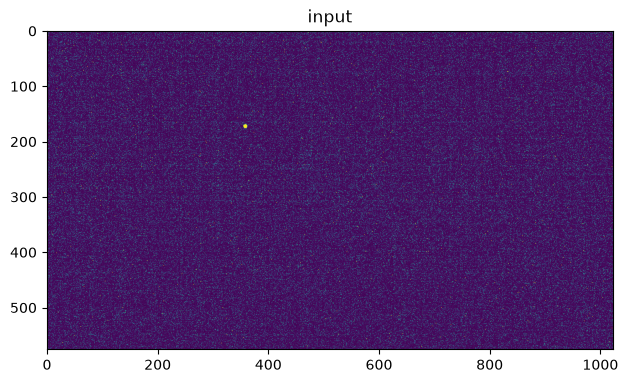

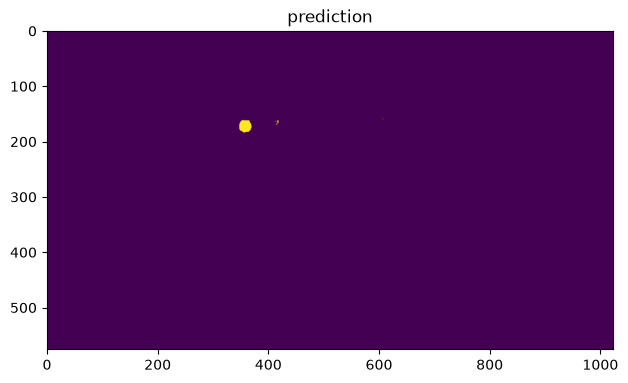

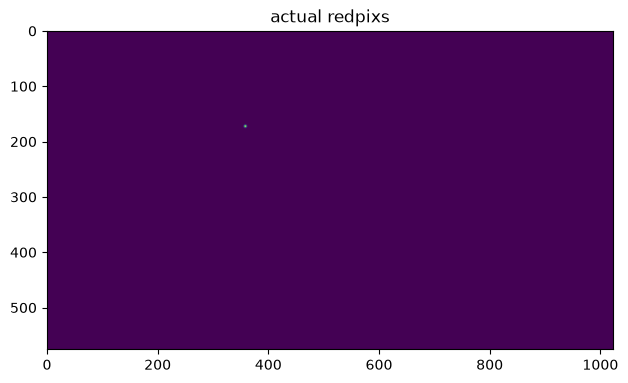

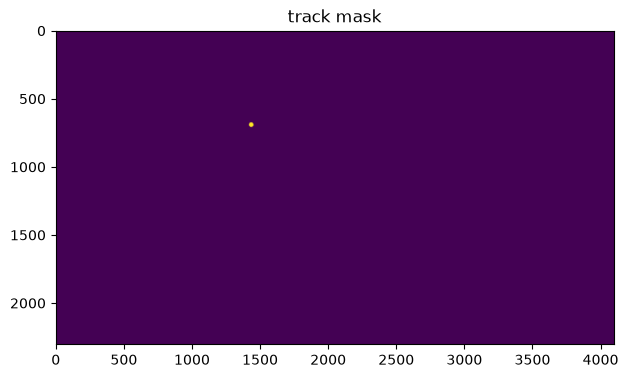

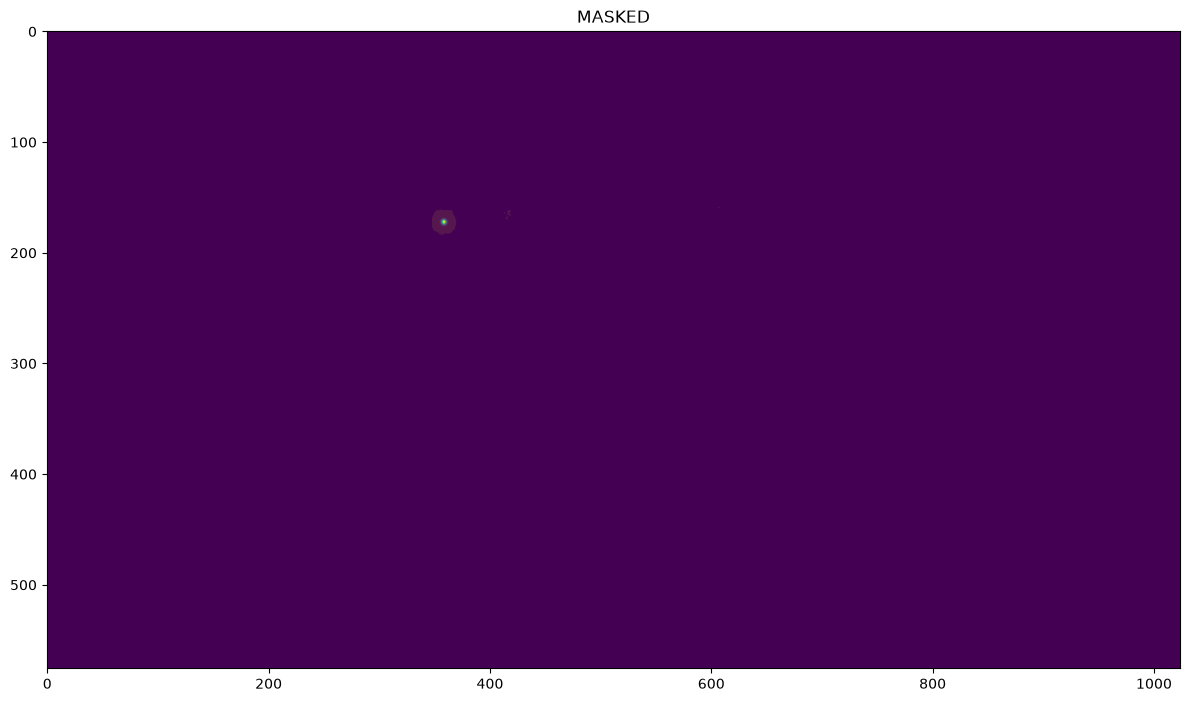

10366
10366


In [43]:
net_file = "2026_Jul_23__16:17_best_model_base16_res_drop.pt"

net_path = os.path.join(net_folder, net_file)
device = "cuda"

net = cygnet.SkipNet(16).to(device)
net.load_state_dict(torch.load(net_path, weights_only=False)['model_state_dict'])
net.eval()

ttt = 0.15
sspred = get_prediction(net, raw_in, ttt).cpu()

print(sspred.min().item())
print(sspred.max().item())

rmin = 0.00305
rmax = 0.0031

mask = (redpix > 0)

cygnet.quickplot(raw_in.squeeze(), "input", rmax, rmin)
cygnet.quickplot(sspred.cpu().squeeze(), "prediction", None, None)
cygnet.quickplot(redpix_gt.squeeze(), "actual redpixs", None, None)
cygnet.quickplot(mask.squeeze(), "track mask", None, None)

cygnet.debug_plot(redpix_gt.squeeze(), sspred.cpu().squeeze(), 0.1, vmin=None, vmax=None)

u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
masked = np.where(u_pred, redpix.squeeze(), 0)
print(compute_energy(redpix))
print(compute_energy(masked))

# cygnet.quickplot(masked.squeeze(), "masked values", None, None)

In [ ]:
# loop su tutte

num = len(os.listdir(raw_path))
recompute = False

if recompute:
	for idx in range(num):
		raw, redpix = load_pic_pair(idx)
		raw_in = cygnet.itrtr(in_t(raw))
		redpix_gt = cygnet.itrtr(in_t(redpix))
		sspred = get_prediction(net, raw_in, ttt).cpu()
		mask = (redpix > 0)
		u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
		masked = np.where(u_pred, redpix.squeeze(), 0)

		en_tot = compute_energy(redpix)
		en_seen = compute_energy(masked)

		en_missed = en_tot - en_seen
		if en_missed > 0:
			print(f"missed some energy in picture {idx}: {en_missed} out of {en_tot} counts" )
			print(f"missed {en_missed/en_tot * 100}% of the energy")
			print()

"""
missed some energy in picture 505: 55
missed 0.07923930269413629% of the energy

missed some energy in picture 512: 156
missed 0.19846065771897464% of the energy

missed some energy in picture 515: 1
missed 0.0005771006463527238% of the energy

missed some energy in picture 516: 4
missed 0.006977393245883338% of the energy

missed some energy in picture 541: 391
missed 3.7015999242639404% of the energy

missed some energy in picture 546: 28
missed 0.009769952511052258% of the energy

missed some energy in picture 551: 3
missed 0.013559934912312421% of the energy

missed some energy in picture 560: 24
missed 0.019138145513699724% of the energy

missed some energy in picture 562: 619
missed 1.2714649576863035% of the energy

missed some energy in picture 616: 294
missed 100.0% of the energy
"""

'\nmissed some energy in picture 505: 55\nmissed 0.07923930269413629% of the energy\n\nmissed some energy in picture 512: 156\nmissed 0.19846065771897464% of the energy\n\nmissed some energy in picture 515: 1\nmissed 0.0005771006463527238% of the energy\n\nmissed some energy in picture 516: 4\nmissed 0.006977393245883338% of the energy\n\nmissed some energy in picture 541: 391\nmissed 3.7015999242639404% of the energy\n\nmissed some energy in picture 546: 28\nmissed 0.009769952511052258% of the energy\n\nmissed some energy in picture 551: 3\nmissed 0.013559934912312421% of the energy\n\nmissed some energy in picture 560: 24\nmissed 0.019138145513699724% of the energy\n\nmissed some energy in picture 562: 619\nmissed 1.2714649576863035% of the energy\n\nmissed some energy in picture 616: 294\nmissed 100.0% of the energy\n'

In [ ]:
# ottimizzazione soglia

t_list = [0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3]
recompute = False

avg_miss_list = []
avg_compression_list = []

if recompute:
	for val in t_list:
		en_missed_percent_list = []
		compression_list = []

		for idx in range(num):
			raw, redpix = load_pic_pair(idx)
			raw_in = cygnet.itrtr(in_t(raw))
			redpix_gt = cygnet.itrtr(in_t(redpix))
			sspred = get_prediction(net, raw_in, val).cpu()
			mask = (redpix > 0)
			u_pred = upscaler_t(sspred.squeeze().unsqueeze(0))
			masked = np.where(u_pred, redpix.squeeze(), 0)

			en_tot = compute_energy(redpix)
			en_seen = compute_energy(masked)

			en_missed = en_tot - en_seen
			en_missed_percent = en_missed/en_tot * 100
			compression = sspred.float().mean().item()

			en_missed_percent_list.append(en_missed_percent)
			compression_list.append(compression)

		avg_miss = np.array(en_missed_percent_list).mean().item()
		avg_miss_list.append(avg_miss)

		avg_comp = np.array(compression_list).mean().item()
		avg_compression_list.append(avg_comp)